In [2]:
import requests
import pandas as pd

url = ("https://api.census.gov/data/2024/acs/acs5?get=group(B20004)&for=state:*")

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data[1:],columns=data[0])

In [3]:
## drop all margin of error columns and additional columns created by API with NONE as output
df.columns = df.columns.astype(str)
df = df[[col for col in df.columns if not (col.endswith('M') or col.endswith('A'))]]

In [4]:
## keep only 6 first columns since rest are split by gender
df = df.iloc[:, :6]

In [5]:
## rename columns 
df.columns = [
    "Total",
    "Less than high school graduate",
    "High school graduate",
    "Some college or associate's degree",
    "Bachelor's degree",
    "Graduate or professional degree"
]

In [6]:
## index dataframe by states
states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 
    'Delaware','District of Coluumbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 
    'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 
    'Wisconsin', 'Wyoming', 'Puerto Rico'
]
df.index = states

In [7]:
## remove Coluumbia and Puerto Rico since not official states
df = df.drop(['District of Coluumbia', 'Puerto Rico'], errors='ignore')

In [8]:
## Dataframe for earnings vs education by State
Earnings_By_State = df

In [9]:
## Save as CSV file
Earnings_By_State.to_csv("Earnings_By_State.csv", index=True)

In [10]:
Earnings_By_State

,Total,Less than high school graduate,High school graduate,Some college or associate's degree,Bachelor's degree,Graduate or professional degree
Alabama,46831,30696,37156,43231,61115,75030
Alaska,58591,35441,44678,54961,71035,92382
Arizona,51402,34212,40874,47651,67417,84105
Arkansas,44499,31882,36880,41256,57697,74020
California,56395,32480,41382,50157,80933,111188
Colorado,60455,37820,45140,50210,73999,90992
Connecticut,61786,34099,44726,51238,79601,99061
Delaware,53037,35002,40675,47864,68176,87287
Florida,46867,30508,36593,43852,59953,78498
Georgia,50458,32349,37841,44633,67868,84480


In [36]:
## create new dataframe for county: 

url = "https://api.census.gov/data/2024/acs/acs5?get=group(B20004)&for=county:*&in=state:*"
response = requests.get(url)
data = response.json()
df_county = pd.DataFrame(data[1:], columns=data[0])

In [38]:
## get rid of all margin of error and additional columns

df_county.columns = df_county.columns.astype(str)
df_county = df_county[[col for col in df_county.columns if not (col.endswith('M') or col.endswith('A'))]]

In [39]:
## index rows by county NAME column

county_col = df_county.columns[-3]
df_county = df_county.set_index(county_col)

In [40]:
## keep only first six columns
df_county = df_county.iloc[:, :6]

In [41]:
## rename columns 

df_county.columns = [
    "Total",
    "Less than high school graduate",
    "High school graduate",
    "Some college or associate's degree",
    "Bachelor's degree",
    "Graduate or professional degree"
]

In [42]:
## remove all counties in Puerto Rico and Columbia

df_county = df_county[~df_county.index.str.endswith(("Puerto Rico", "Columbia"))]

In [43]:
## remove all counties which have negative or missing values 
df_county = df_county.apply(pd.to_numeric, errors='coerce')
df_county = df_county.dropna()
df_county = df_county[(df_county >= 0).all(axis=1)]

In [44]:
Earnings_By_County = df_county

In [45]:
Earnings_By_County

,Total,Less than high school graduate,High school graduate,Some college or associate's degree,Bachelor's degree,Graduate or professional degree
NAME,,,,,,
"Autauga County, Alabama",49028,40873,36261,47554,61673,88884
"Baldwin County, Alabama",50280,35339,41214,43700,66858,76200
"Barbour County, Alabama",35453,30551,32988,40000,48125,49349
"Bibb County, Alabama",36898,24073,31602,40480,48089,56500
"Blount County, Alabama",45785,33292,37479,49488,54912,75918
...,...,...,...,...,...,...
"Sublette County, Wyoming",55058,65750,32424,47132,66032,72296
"Sweetwater County, Wyoming",52763,31232,41385,52065,62591,78750
"Teton County, Wyoming",58405,41905,50152,55602,58857,95453


In [46]:
Earnings_By_County.to_csv("Earnings_By_County.csv", index=True)

In [47]:
!pip install pandasql

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [48]:
import pandas as pd
from pandasql import sqldf

In [49]:
# read cleaned up files using pandas 
by_state = pd.read_csv("Earnings_By_State.csv")
by_county = pd.read_csv("Earnings_By_County.csv")

In [50]:
# rename the column back to state 
by_state = by_state.rename(columns = {"Unnamed: 0": "State"})

In [51]:
# Average total income in U.S. 
avg_income = sqldf("""SELECT 
                            AVG(total) AS Total, 
                            AVG(`Less than high school graduate`) AS `Less than high school graduate`, 
                            AVG(`High school graduate`) AS `High school graduate`, 
                            AVG(`Some college or associate's degree`) AS `Some college or associate's degree`,
                            AVG(`Bachelor's degree`) AS `Bachelor's degree`,
                            AVG(`Graduate or professional degree`) AS `Graduate or professional degree`
                      FROM by_state""")
avg_income = avg_income.round(0).astype(int) # round to whole numbers 

In [52]:
# State with highest average total income 
highest_avg_state = sqldf("SELECT * FROM by_state ORDER BY total DESC LIMIT 1")

# State with lowest average total income 
lowest_avg_state = sqldf("SELECT * FROM by_state ORDER BY total LIMIT 1")

# California average income 
CA_avg_state = sqldf("SELECT * FROM by_state WHERE state = 'California' ORDER BY total")

In [53]:
# State with highest average income for each education level 

# Less than high school graduate education level
lessHS_avg_state = sqldf("SELECT * FROM by_state ORDER BY `less than high school graduate` DESC LIMIT 1")
# High school graduate education level 
HS_avg_state = sqldf("SELECT * FROM by_state ORDER BY `high school graduate` DESC LIMIT 1")
# Some college or Associate's degree education level 
somedegree_avg_state = sqldf("SELECT * FROM by_state ORDER BY `some college or associate's degree` DESC LIMIT 1")
# Bachelor's degree education level 
bachdegree_avg_state = sqldf("SELECT * FROM by_state ORDER BY `bachelor's degree` DESC LIMIT 1")
# Above Bachelor's degree education level 
abovebach_avg_state = sqldf("SELECT * FROM by_state ORDER BY `graduate or professional degree` DESC LIMIT 1")

# State with lowest average income level for each education level 

# Less than high school graduate education level
lessHS_avg_state = sqldf("SELECT * FROM by_state ORDER BY `less than high school graduate` LIMIT 1")
# High school graduate education level 
HS_avg_state = sqldf("SELECT * FROM by_state ORDER BY `high school graduate` LIMIT 1")
# Some college or Associate's degree education level 
somedegree_avg_state = sqldf("SELECT * FROM by_state ORDER BY `some college or associate's degree` LIMIT 1")
# Bachelor's degree education level 
bachdegree_avg_state = sqldf("SELECT * FROM by_state ORDER BY `bachelor's degree` LIMIT 1")
# Above Bachelor's degree education level 
abovebach_avg_state = sqldf("SELECT * FROM by_state ORDER BY `graduate or professional degree` LIMIT 1")

In [54]:
# Split the name into both county and state so they can be grouped later
by_county[["County", "State"]] = by_county.NAME.str.split(",", expand = True)

In [55]:
# County with highest average income 
highest_avg_county = sqldf("SELECT * FROM by_county ORDER BY total DESC LIMIT 1")

# County with lowest average income 
lowest_avg_county = sqldf("SELECT * FROM by_county ORDER BY total LIMIT 1")

# Only California counties 
CA_avg_county = sqldf("SELECT * FROM by_county WHERE state = ' California' ORDER BY total DESC")

In [56]:
# County with highest average income per state 
high_county_per = sqldf("""SELECT 
                               County, 
                               C.State, 
                               Name, 
                               Total, 
                               `Less than high school graduate`, 
                               `High school graduate`, 
                               `Some college or associate's degree`,
                               `Bachelor's degree`,
                               `Graduate or professional degree`
                           FROM
                               (SELECT State, MAX(total) AS highest FROM by_county GROUP BY state) AS high 
                           JOIN 
                               by_county AS C
                           ON 
                               high.state = C.state AND high.highest = C.total""")

In [57]:
# County with lowest average income per state 
low_county_per = sqldf("""SELECT
                              County, 
                              C.State, 
                              Name, 
                              Total, 
                              `Less than high school graduate`, 
                              `High school graduate`, 
                              `Some college or associate's degree`,
                              `Bachelor's degree`,
                              `Graduate or professional degree`
                          FROM
                              (SELECT State, MIN(total) AS lowest FROM by_county GROUP BY state) AS low 
                          JOIN 
                              by_county AS C
                          ON 
                              low.state = C.state AND low.lowest = C.total""")

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [59]:
### Scatter + Regression Line ###

# Get the cleaned data and convert the earnings columns into numeric values

df = pd.read_csv("Earnings_By_State.csv")
df.iloc[:,1:] = df.iloc[:,1:].apply(pd.to_numeric)

#Get the national average earnings for each educational level by averaging across all of the states
US_average = df.iloc[:,1:].mean()

#Convert the averages into a dataframe
US_average_df = US_average.reset_index()
US_average_df.columns = ["Education_Level", "Earnings"]


In [60]:
#Convert the education level categories into numeric levels

education_order = {
    "Less than high school graduate": 1,
    "High school graduate": 2,
    "Some college or associate's degree": 3,
    "Bachelor's degree": 4,
    "Graduate or professional degree": 5
}

In [61]:
US_average_df["Education_Number"] = US_average_df["Education_Level"].map(education_order)

In [62]:
US_average_df

,Education_Level,Earnings,Education_Number
0,Total,52462.84,NaN
1,Less than high school graduate,33962.22,1.0
2,High school graduate,40654.86,2.0
3,Some college or associate's degree,47107.56,3.0
4,Bachelor's degree,66242.46,4.0
5,Graduate or professional degree,84168.54,5.0


In [63]:
#Calculate the regression coefficients and return the slope and intercept of the best-fit line. Get rid of any NaN.

US_average_df = US_average_df.dropna()
slope, intercept = np.polyfit(US_average_df["Education_Number"], US_average_df["Earnings"], 1)
print("Slope (β1):", slope)
print("Intercept (β0):", intercept)

Slope (β1): 12600.024000000003
Intercept (β0): 16627.055999999997


In [64]:
#Create predicted values for the regression line

x_values = US_average_df["Education_Number"]
y_values = slope * x_values + intercept

Text(0.5, 1.0, 'Regression of Education Lelvel vs. Median Earnings in the US')

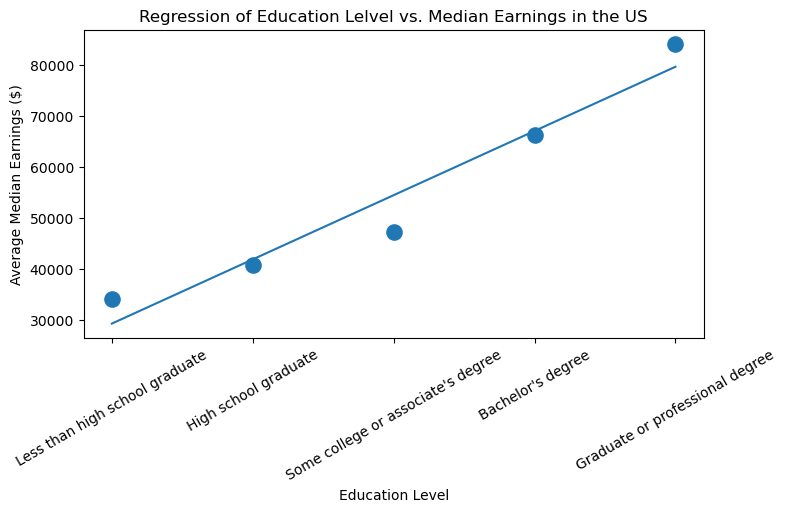

In [65]:
#Plot the data points and the regression line

plt.figure(figsize = (8, 4))

#Make a scatter plot of the actual data points

plt.scatter(US_average_df["Education_Number"], US_average_df["Earnings"], s = 120)

#Plot the regression line

plt.plot(x_values, y_values)

# Replace the numeric education level values with named labels
plt.xticks(
    [1, 2, 3, 4, 5],
    [
        "Less than high school graduate",
        "High school graduate",
        "Some college or associate's degree",
        "Bachelor's degree",
        "Graduate or professional degree"
    ],
    rotation = 30
)

#Add a title and labels

plt.xlabel("Education Level")
plt.ylabel("Average Median Earnings ($)")
plt.title("Regression of Education Lelvel vs. Median Earnings in the US")

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [67]:
### Grouped Bar Chart (California, Highest State, Lowest State) ###

#Load the dataset
each_state = pd.read_csv("Earnings_By_State.csv")

#Rename the first column
if "Unnamed: 0" in each_state.columns:
    each_state = each_state.rename(columns={"Unnamed: 0": "State"})
    
#Convert the earnings columns into numeric
for col in each_state.columns[1:]:
    each_state[col] = pd.to_numeric(each_state[col], errors = "coerce")

#Identify the state with the highest median income
highest_state = each_state.loc[each_state["Total"].idxmax()]["State"]

#Identify the state with the lowest median income
lowest_state = each_state.loc[each_state["Total"].idxmin()]["State"]

#Identify the income in California
california = "California"

print("Highest income state:", highest_state)
print("Lowest income state:", lowest_state)

Highest income state: Massachusetts
Lowest income state: Mississippi


In [68]:
#Only work with the selected states
selected_states = each_state[each_state["State"].isin([california, highest_state, lowest_state])]

#Prepare the education categories
education_levels = [
    "Less than high school graduate",
    "High school graduate",
    "Some college or associate's degree",
    "Bachelor's degree",
    "Graduate or professional degree"
]

#Get the earnings for each state
Cali_data = selected_states[selected_states["State"] == california][education_levels].values.flatten()
highest_data = selected_states[selected_states["State"] == highest_state][education_levels].values.flatten()
lowest_data = selected_states[selected_states["State"] == lowest_state][education_levels].values.flatten()

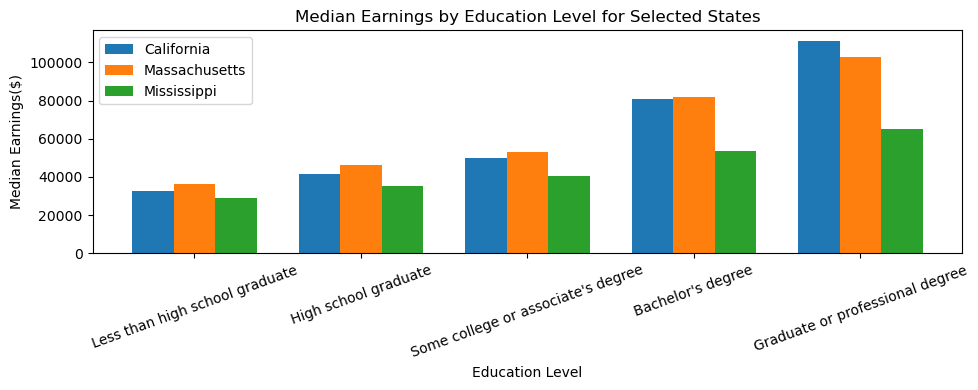

In [69]:
# Create the grouped bar chart

#Create the x positions
x = np.arange(len(education_levels))
width = 0.25
plt.figure(figsize = (10, 4))

#Create the plot bars
plt.bar(x - width, Cali_data, width, label = "California")
plt.bar(x, highest_data, width, label= highest_state)
plt.bar(x + width, lowest_data, width, label= lowest_state)

#Labels and title
plt.xlabel("Education Level")
plt.ylabel("Median Earnings($)")
plt.title("Median Earnings by Education Level for Selected States")

plt.xticks(
    x,
    [
        "Less than high school graduate",
        "High school graduate",
        "Some college or associate's degree",
        "Bachelor's degree",
        "Graduate or professional degree"
    ],
    rotation = 20
)

plt.legend()
plt.tight_layout()
plt.show()

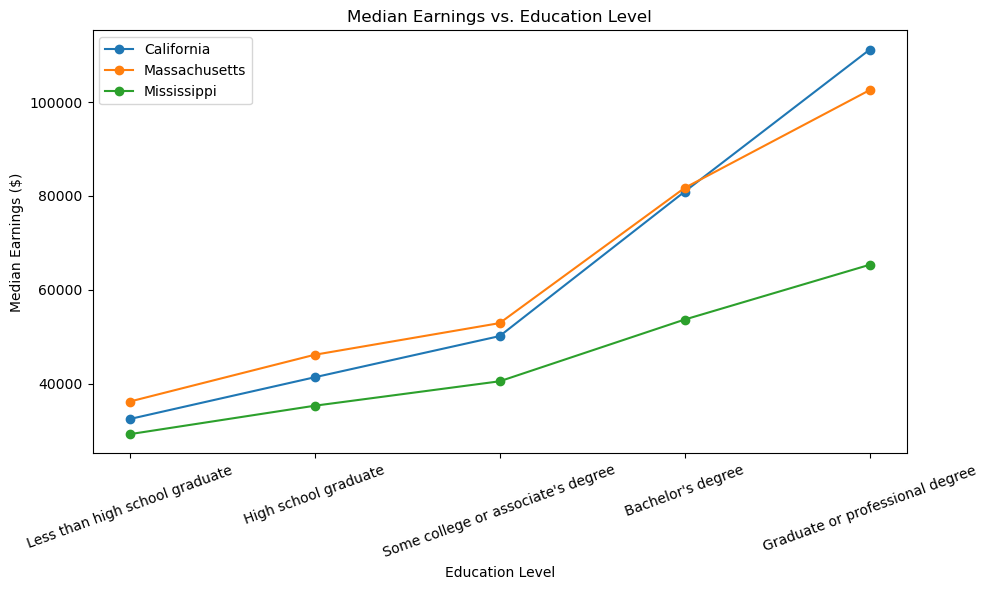

In [71]:
### Line Plot of Income vs. Education (California, Highest State, Lowest State) ###

plt.figure(figsize = (10, 6))

#Plot a line for each state
for _, row in selected_states.iterrows():
    plt.plot(
        education_levels,
        row[education_levels],
        marker = "o",
        label = row["State"]
    )

#Add labels and a title
plt.xlabel("Education Level")
plt.ylabel("Median Earnings ($)")
plt.title("Median Earnings vs. Education Level")

plt.xticks(rotation = 20)
plt.legend()
plt.tight_layout()
plt.show()